<a href="https://colab.research.google.com/github/nazal-prog/ML-Lab-Final-Group-3/blob/main/notebooks%5CData_Analyst_3_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train_clean.csv to train_clean.csv


In [ ]:
import os

print(os.listdir())

['.config', 'train_clean.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("train_clean.csv")

print(df.head())

                                             message  label
0      ta-daaaaa! i am home babe, are you still up ?      0
1    yup having my lunch buffet now.. u eat already?      0
2     ok anyway no need to change with what you said      0
3                        all e best 4 ur exam later.      0
4  now only i reached home. . . i am very tired n...      0


In [ ]:
df = pd.read_csv("train_clean.csv")

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.head())
print(df.shape)

Saving train_clean.csv to train_clean (1).csv
                                             message  label
0      ta-daaaaa! i am home babe, are you still up ?      0
1    yup having my lunch buffet now.. u eat already?      0
2     ok anyway no need to change with what you said      0
3                        all e best 4 ur exam later.      0
4  now only i reached home. . . i am very tired n...      0
(4135, 2)


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

Dataset Shape: (4135, 2)

Column Names:
['message', 'label']

First 5 Rows:


,message,label
0,"ta-daaaaa! i am home babe, are you still up ?",0
1,yup having my lunch buffet now.. u eat already?,0
2,ok anyway no need to change with what you said,0
3,all e best 4 ur exam later.,0
4,now only i reached home. . . i am very tired n...,0



Last 5 Rows:


,message,label
4130,xclusive@clubsaisai 2morow 28/5 soiree special...,1
4131,umma my life and vava umma love you lot dear,0
4132,whore you are unbelievable.,0
4133,becoz its &lt;#&gt; jan whn al the post ofice ...,0
4134,did you stitch his trouser,0


In [ ]:
print(df.dtypes)

message    object
label       int64
dtype: object


In [ ]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

print("\nMissing Percentage:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values:
message    0
label      0
dtype: int64

Missing Percentage:
message    0.0
label      0.0
dtype: float64


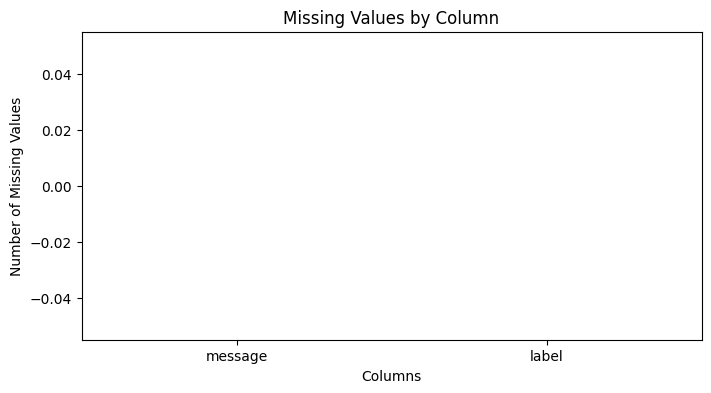

In [ ]:
plt.figure(figsize=(8, 4))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5


In [ ]:
duplicates = df[df.duplicated(keep=False)]

display(duplicates)

,message,label
875,a £400 xmas reward is waiting for you! our com...,1
963,you have won a nokia 7250i. this is what you g...,1
971,a £400 xmas reward is waiting for you! our com...,1
1267,you have won a nokia 7250i. this is what you g...,1
2889,"if you don't, your prize will go to another cu...",1
3209,gent! we are trying to contact you. last weeke...,1
3252,dear 0776xxxxxxx u've been invited to xchat. t...,1
3639,gent! we are trying to contact you. last weeke...,1
3647,dear 0776xxxxxxx u've been invited to xchat. t...,1
3721,"if you don't, your prize will go to another cu...",1


In [ ]:
class_counts = df['label'].value_counts()

print(class_counts)

label
0    3613
1     522
Name: count, dtype: int64


In [ ]:
df['class_name'] = df['label'].map({
    0: 'Ham',
    1: 'Spam'
})

print(df['class_name'].value_counts())

class_name
Ham     3613
Spam     522
Name: count, dtype: int64


In [ ]:


target = 'label'

print("Target Variable:", target)
print("Target Data Type:", df[target].dtype)

print("\nTarget Values:")
print(df[target].value_counts())

print("\nTarget Meaning:")
print("0 = Ham")
print("1 = Spam")

Target Variable: label
Target Data Type: int64

Target Values:
label
0    3613
1     522
Name: count, dtype: int64

Target Meaning:
0 = Ham
1 = Spam


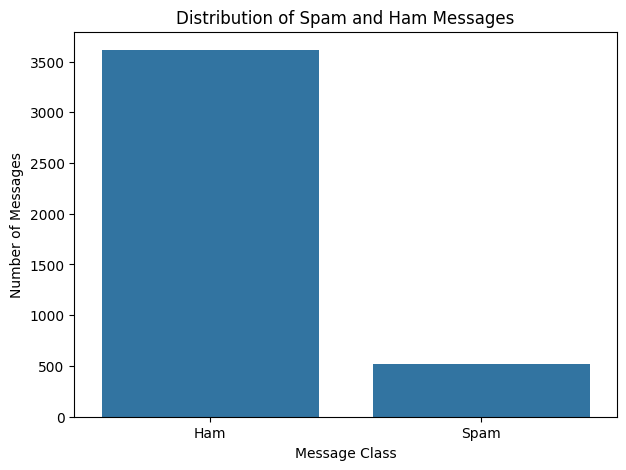

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='class_name'
)

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Class")
plt.ylabel("Number of Messages")

plt.show()

In [ ]:
# ==============================
# NUMERICAL GROUP COMPARISON
# ==============================

group_summary = df.groupby('class_name')[
    numeric_features
].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
])

display(group_summary)

message_length                                        word_count  \
                    count        mean median        std min  max      count   
class_name                                                                    
Ham                  3613   70.908386   53.0  56.475611   2  910       3613   
Spam                  522  137.683908  148.0  30.009750  13  223        522   

                                                 characters_no_spaces  \
                 mean median        std min  max                count   
class_name                                                              
Ham         14.257957   11.0  11.189196   1  171                 3613   
Spam        23.689655   25.0   5.926570   2   35                  522   

                                                   
                  mean median        std min  max  
class_name                                         
Ham          57.650429   43.0  45.535918   2  740  
Spam        114.994253  124.0  25.089895  12  190

In [ ]:
class_percentage = df['class_name'].value_counts(normalize=True) * 100

print(class_percentage)

class_name
Ham     87.376058
Spam    12.623942
Name: proportion, dtype: float64


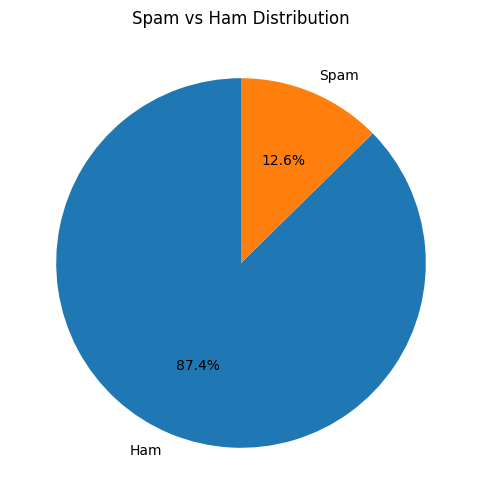

In [ ]:
plt.figure(figsize=(6, 6))

plt.pie(
    class_counts,
    labels=['Ham', 'Spam'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Spam vs Ham Distribution")

plt.show()

In [ ]:
df['message_length'] = df['message'].str.len()

In [ ]:
print(df[['message', 'message_length']].head())

                                             message  message_length
0      ta-daaaaa! i am home babe, are you still up ?              45
1    yup having my lunch buffet now.. u eat already?              47
2     ok anyway no need to change with what you said              46
3                        all e best 4 ur exam later.              27
4  now only i reached home. . . i am very tired n...              71


In [ ]:
df['word_count'] = df['message'].str.split().str.len()

print(df[['message', 'word_count']].head())

                                             message  word_count
0      ta-daaaaa! i am home babe, are you still up ?          10
1    yup having my lunch buffet now.. u eat already?           9
2     ok anyway no need to change with what you said          10
3                        all e best 4 ur exam later.           7
4  now only i reached home. . . i am very tired n...          17


In [ ]:
df['characters_no_spaces'] = df['message'].str.replace(
    ' ',
    '',
    regex=False
).str.len()

print(df[['message_length',
          'word_count',
          'characters_no_spaces']].describe())

In [ ]:
print(df[['message_length',
          'word_count',
          'characters_no_spaces']].describe())

       message_length   word_count  characters_no_spaces
count     4135.000000  4135.000000           4135.000000
mean        79.338089    15.448609             64.889480
std         58.242709    11.118929             47.474523
min          2.000000     1.000000              2.000000
25%         36.000000     7.000000             29.500000
50%         61.000000    12.000000             49.000000
75%        119.000000    22.000000             96.000000
max        910.000000   171.000000            740.000000


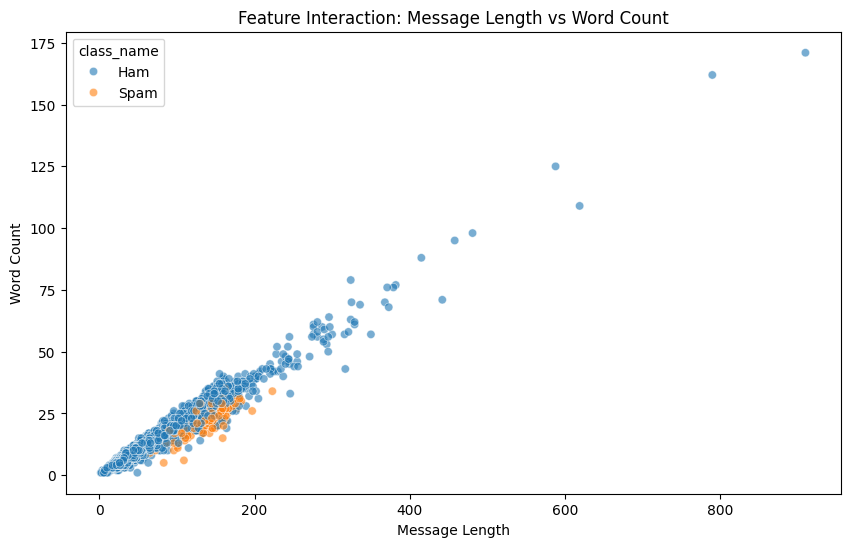

In [ ]:
# ==============================
# FEATURE INTERACTION ANALYSIS
# ==============================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='message_length',
    y='word_count',
    hue='class_name',
    alpha=0.6
)

plt.title("Feature Interaction: Message Length vs Word Count")
plt.xlabel("Message Length")
plt.ylabel("Word Count")

plt.show()

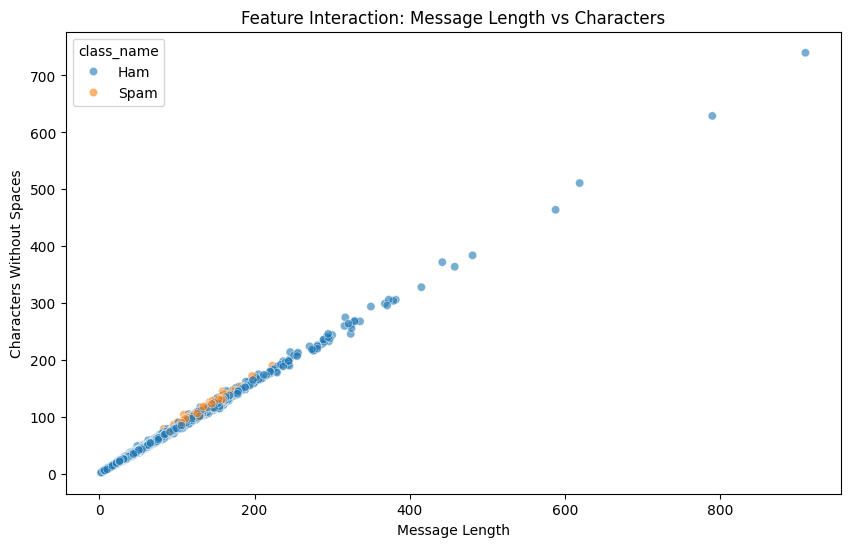

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='message_length',
    y='characters_no_spaces',
    hue='class_name',
    alpha=0.6
)

plt.title("Feature Interaction: Message Length vs Characters")
plt.xlabel("Message Length")
plt.ylabel("Characters Without Spaces")

plt.show()

In [ ]:
# ==============================
# TARGET-WISE SUMMARY
# ==============================

target_summary = df.groupby('class_name')[
    numeric_features
].agg(['mean', 'median', 'std'])

display(target_summary)

message_length                   word_count                    \
                     mean median        std       mean median        std   
class_name                                                                 
Ham             70.908386   53.0  56.475611  14.257957   11.0  11.189196   
Spam           137.683908  148.0  30.009750  23.689655   25.0   5.926570   

           characters_no_spaces                    
                           mean median        std  
class_name                                         
Ham                   57.650429   43.0  45.535918  
Spam                 114.994253  124.0  25.089895

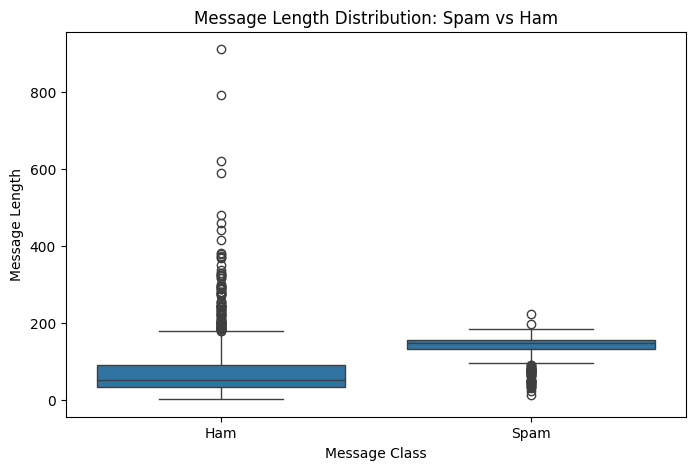

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='class_name',
    y='message_length'
)

plt.title("Message Length Distribution: Spam vs Ham")
plt.xlabel("Message Class")
plt.ylabel("Message Length")

plt.show()

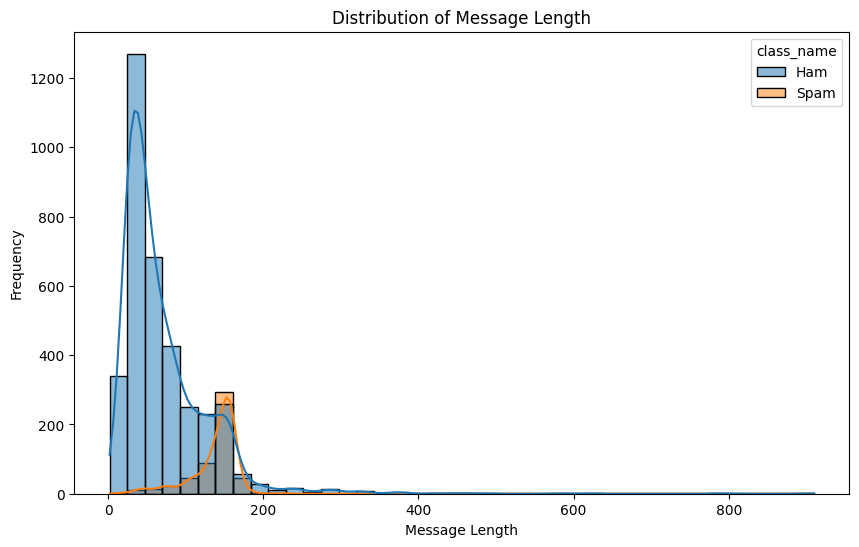

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='message_length',
    hue='class_name',
    bins=40,
    kde=True
)

plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

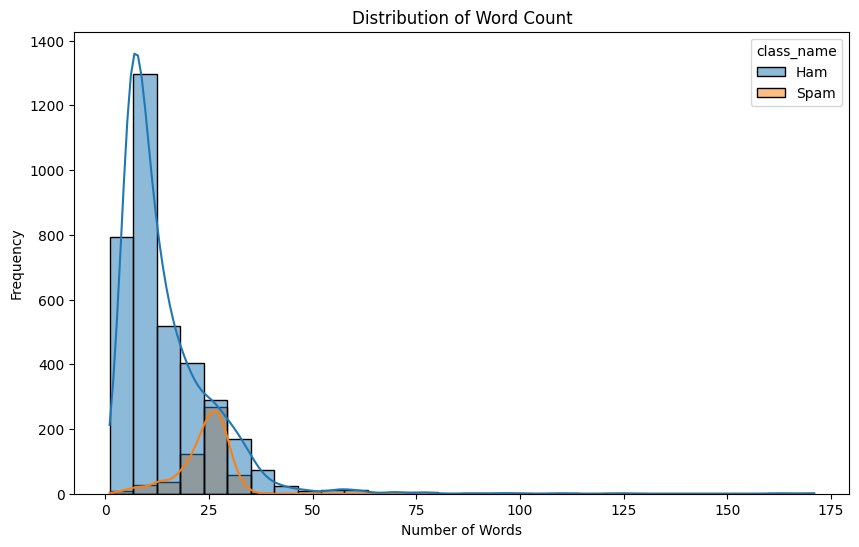

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='word_count',
    hue='class_name',
    bins=30,
    kde=True
)

plt.title("Distribution of Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

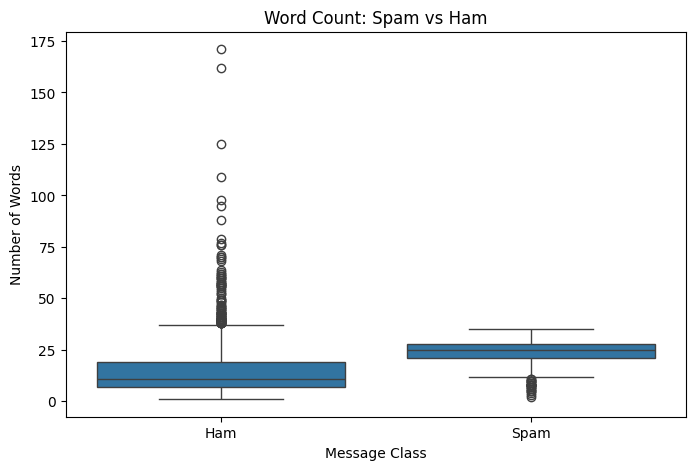

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='class_name',
    y='word_count'
)

plt.title("Word Count: Spam vs Ham")
plt.xlabel("Message Class")
plt.ylabel("Number of Words")

plt.show()

In [ ]:
numeric_features = [
    'message_length',
    'word_count',
    'characters_no_spaces'
]

skewness = df[numeric_features].skew()

print("Skewness:")
print(skewness)

Skewness:
message_length          2.639657
word_count              2.840591
characters_no_spaces    2.584199
dtype: float64


In [ ]:
for feature in numeric_features:
    value = df[feature].skew()

    if value > 1:
        interpretation = "Highly right-skewed"
    elif value > 0.5:
        interpretation = "Moderately right-skewed"
    elif value < -1:
        interpretation = "Highly left-skewed"
    elif value < -0.5:
        interpretation = "Moderately left-skewed"
    else:
        interpretation = "Approximately symmetric"

    print(feature, ":", round(value, 3), "→", interpretation)

message_length : 2.64 → Highly right-skewed
word_count : 2.841 → Highly right-skewed
characters_no_spaces : 2.584 → Highly right-skewed


In [ ]:
for feature in numeric_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    print("\nFeature:", feature)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


Feature: message_length
Lower Bound: -88.5
Upper Bound: 243.5
Number of Outliers: 51

Feature: word_count
Lower Bound: -15.5
Upper Bound: 44.5
Number of Outliers: 55

Feature: characters_no_spaces
Lower Bound: -70.25
Upper Bound: 195.75
Number of Outliers: 52


In [ ]:


spearman_corr = df[
    ['label',
     'message_length',
     'word_count',
     'characters_no_spaces']
].corr(method='spearman')

print("Spearman Correlation Matrix:")
display(spearman_corr)

Spearman Correlation Matrix:


,label,message_length,word_count,characters_no_spaces
label,1.000000,0.427954,0.358500,0.442189
message_length,0.427954,1.000000,0.971891,0.998183
word_count,0.358500,0.971891,1.000000,0.957745
characters_no_spaces,0.442189,0.998183,0.957745,1.000000


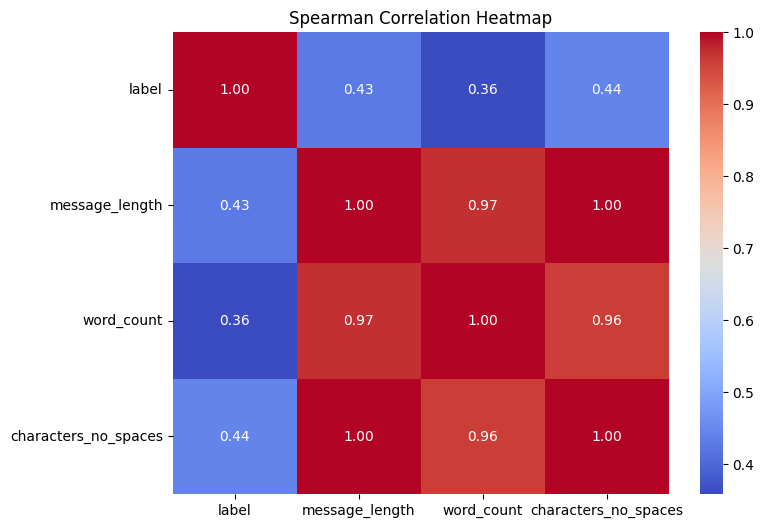

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Spearman Correlation Heatmap")
plt.show()

In [ ]:
correlation_matrix = df[
    ['label',
     'message_length',
     'word_count',
     'characters_no_spaces']
].corr()

print(correlation_matrix)

                         label  message_length  word_count  \
label                 1.000000        0.380822    0.281756   
message_length        0.380822        1.000000    0.974382   
word_count            0.281756        0.974382    1.000000   
characters_no_spaces  0.401210        0.998612    0.961184   

                      characters_no_spaces  
label                             0.401210  
message_length                    0.998612  
word_count                        0.961184  
characters_no_spaces              1.000000  


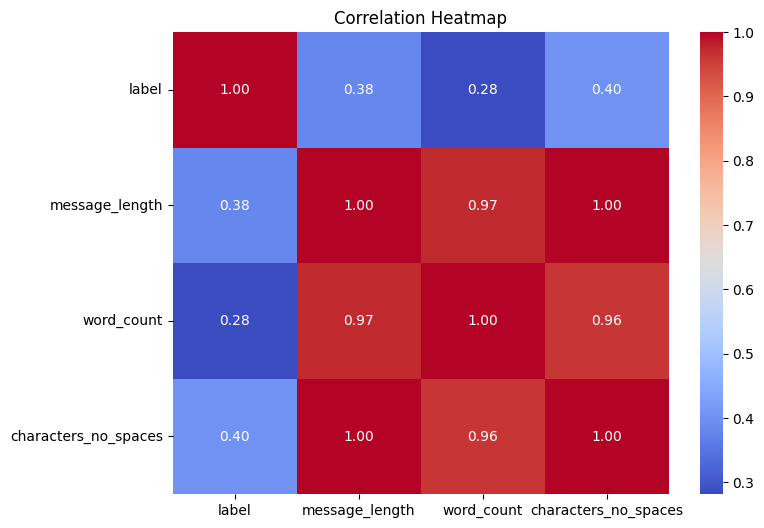

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
spam_messages = df[df['label'] == 1]['message']

spam_words = ' '.join(spam_messages).lower().split()

spam_word_counts = Counter(spam_words)

spam_common_words = spam_word_counts.most_common(20)

print(spam_common_words)

[('to', 469), ('a', 243), ('call', 233), ('your', 189), ('you', 182), ('for', 159), ('the', 146), ('or', 129), ('free', 128), ('2', 125), ('is', 116), ('ur', 105), ('have', 91), ('on', 91), ('and', 87), ('from', 86), ('txt', 85), ('text', 80), ('u', 79), ('reply', 79)]


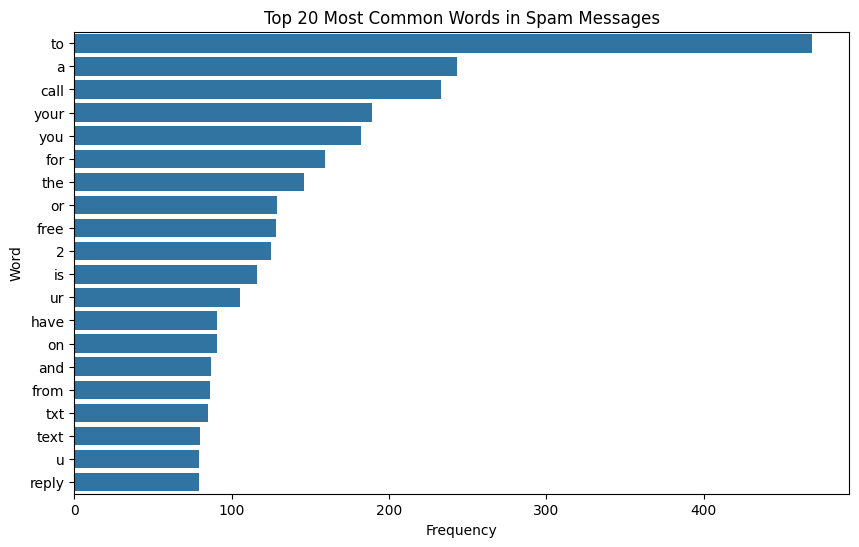

In [ ]:
words = [x[0] for x in spam_common_words]
counts = [x[1] for x in spam_common_words]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Common Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [ ]:
# ==============================
# STRONGEST NUMERICAL CORRELATION
# ==============================

numeric_features = [
    'message_length',
    'word_count',
    'characters_no_spaces'
]

corr_matrix = df[numeric_features].corr(method='spearman')

# Remove self-correlations
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

strongest_pair = (
    corr_pairs
    .stack()
    .abs()
    .sort_values(ascending=False)
)

print("Strongest Numerical Feature Correlation:")

if len(strongest_pair) > 0:
    pair = strongest_pair.index[0]
    value = corr_pairs.loc[pair]

    print("Feature 1:", pair[0])
    print("Feature 2:", pair[1])
    print("Spearman Correlation:", round(value, 4))

Strongest Numerical Feature Correlation:
Feature 1: message_length
Feature 2: characters_no_spaces
Spearman Correlation: 0.9982


In [ ]:
df[feature].corr(df['label'])

np.float64(0.40121049190778235)

In [ ]:
# ==============================
# NUMERICAL FEATURE-TARGET ASSOCIATION
# ==============================

association = []

for feature in numeric_features:

    pearson_value = df[feature].corr(
        df['label'],
        method='pearson'
    )

    spearman_value = df[feature].corr(
        df['label'],
        method='spearman'
    )

    association.append({
        'Feature': feature,
        'Pearson Correlation': pearson_value,
        'Spearman Correlation': spearman_value
    })

association_df = pd.DataFrame(association)

display(association_df)

,Feature,Pearson Correlation,Spearman Correlation
0,message_length,0.380822,0.427954
1,word_count,0.281756,0.358500
2,characters_no_spaces,0.401210,0.442189


In [ ]:
ham_messages = df[df['label'] == 0]['message']

ham_words = ' '.join(ham_messages).lower().split()

ham_word_counts = Counter(ham_words)

ham_common_words = ham_word_counts.most_common(20)

print(ham_common_words)

[('i', 1673), ('you', 1288), ('to', 1169), ('the', 874), ('a', 761), ('and', 676), ('u', 638), ('in', 583), ('my', 544), ('is', 512), ('me', 446), ('for', 389), ('of', 388), ('it', 359), ('that', 345), ('have', 341), ('but', 324), ('are', 316), ('so', 304), ("i'm", 298)]


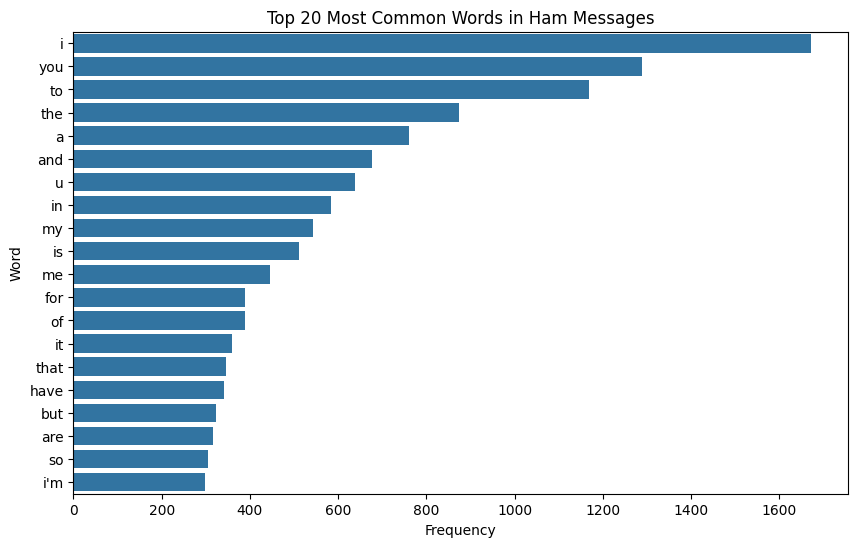

In [ ]:
words = [x[0] for x in ham_common_words]
counts = [x[1] for x in ham_common_words]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Common Words in Ham Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

spam_words_clean = []

for message in spam_messages:

    words = re.findall(r'\b[a-zA-Z]{2,}\b', message.lower())

    for word in words:
        if word not in ENGLISH_STOP_WORDS:
            spam_words_clean.append(word)

spam_counts = Counter(spam_words_clean)

spam_top20 = spam_counts.most_common(20)

print(spam_top20)

[('free', 154), ('ur', 105), ('txt', 104), ('text', 91), ('mobile', 89), ('stop', 86), ('reply', 82), ('claim', 72), ('www', 70), ('prize', 65), ('just', 55), ('cash', 54), ('uk', 52), ('new', 52), ('send', 51), ('won', 51), ('win', 44), ('urgent', 44), ('contact', 42), ('nokia', 41)]


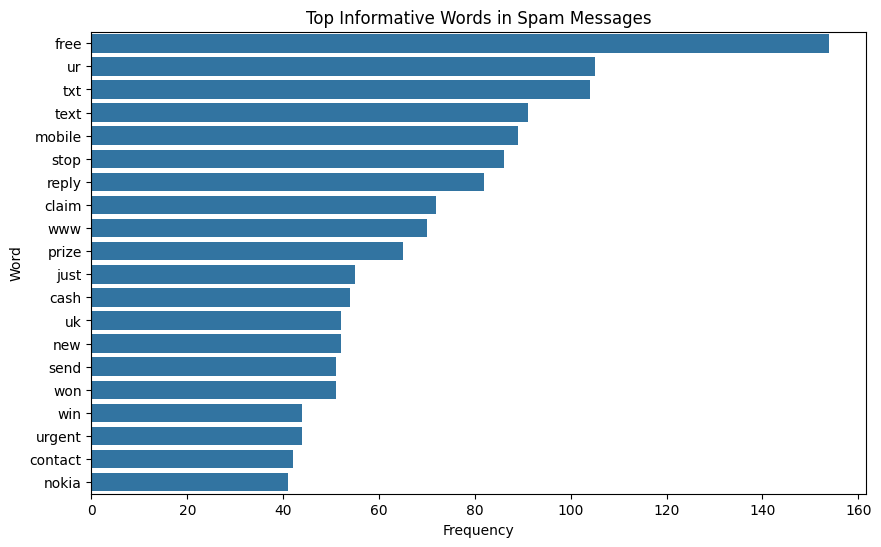

In [ ]:
words = [x[0] for x in spam_top20]
counts = [x[1] for x in spam_top20]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top Informative Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

tfidf_matrix = tfidf.fit_transform(df['message'])

tfidf_words = tfidf.get_feature_names_out()

print("Top TF-IDF Features:")
print(tfidf_words)

Top TF-IDF Features:
['come' 'day' 'free' 'going' 'good' 'got' 'gt' 'just' 'know' 'like' 'll'
 'love' 'lt' 'need' 'ok' 'send' 'text' 'time' 'ur' 'want']


In [ ]:
print("Average message length:")
print(df.groupby('class_name')['message_length'].mean())

print("\nMedian message length:")
print(df.groupby('class_name')['message_length'].median())

Average message length:
class_name
Ham      70.908386
Spam    137.683908
Name: message_length, dtype: float64

Median message length:
class_name
Ham      53.0
Spam    148.0
Name: message_length, dtype: float64


In [ ]:
print("Average word count:")
print(df.groupby('class_name')['word_count'].mean())

print("\nMedian word count:")
print(df.groupby('class_name')['word_count'].median())

Average word count:
class_name
Ham     14.257957
Spam    23.689655
Name: word_count, dtype: float64

Median word count:
class_name
Ham     11.0
Spam    25.0
Name: word_count, dtype: float64


In [ ]:
longest_messages = df.sort_values(
    'message_length',
    ascending=False
)[
    ['message', 'class_name', 'message_length', 'word_count']
].head(10)

display(longest_messages)

,message,class_name,message_length,word_count
1779,for me the love should start with attraction.i...,Ham,910,171
137,the last thing i ever wanted to do was hurt yo...,Ham,790,162
2503,indians r poor but india is not a poor country...,Ham,619,109
3327,sad story of a man - last week was my b'day. m...,Ham,588,125
3799,"good evening sir, hope you are having a nice d...",Ham,481,98
3706,"hey sweet, i was wondering when you had a mome...",Ham,458,95
78,solve d case : a man was found murdered on &lt...,Ham,442,71
3239,"no, i *didn't* mean to post it. i wrote it, an...",Ham,415,88
1729,spoke with uncle john today. he strongly feels...,Ham,382,77
1972,"and that is the problem. you walk around in ""j...",Ham,379,76


In [ ]:
shortest_messages = df.sort_values(
    'message_length',
    ascending=True
)[
    ['message', 'class_name', 'message_length', 'word_count']
].head(10)

display(shortest_messages)

,message,class_name,message_length,word_count
2939,ok,Ham,2,1
2834,ok.,Ham,3,1
3563,yup,Ham,3,1
983,645,Ham,3,1
1315,okie,Ham,4,1
1048,ok..,Ham,4,1
2818,u 2.,Ham,4,2
1990,g.w.r,Ham,5,1
3886,ok...,Ham,5,1
4019,yup...,Ham,6,1


In [ ]:
# ==============================
# CREATE CATEGORICAL FEATURE
# ==============================

df['message_length_category'] = pd.cut(
    df['message_length'],
    bins=3,
    labels=['Short', 'Medium', 'Long']
)

print(df['message_length_category'].value_counts())

message_length_category
Short     4112
Medium      20
Long         3
Name: count, dtype: int64


In [ ]:
# ==============================
# CRAMER'S V
# ==============================

from scipy.stats import chi2_contingency

def cramers_v(x, y):

    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)

    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(
        phi2corr / min(kcorr - 1, rcorr - 1)
    )


cramers_result = cramers_v(
    df['class_name'],
    df['message_length_category']
)

print(
    "Cramer's V between Target and Message Length Category:",
    round(cramers_result, 4)
)

Cramer's V between Target and Message Length Category: 0.018


In [ ]:

features = [
    'message_length',
    'word_count',
    'characters_no_spaces'
]

for feature in features:

    print(
        "\n",
        feature,
        "correlation with label:",
        round(df[feature].corr(df['label']), 4)
    )


 message_length correlation with label: 0.3808

 word_count correlation with label: 0.2818

 characters_no_spaces correlation with label: 0.4012


In [ ]:
summary = pd.DataFrame({
    'Feature': numeric_features,
    'Mean': [df[x].mean() for x in numeric_features],
    'Median': [df[x].median() for x in numeric_features],
    'Std Dev': [df[x].std() for x in numeric_features],
    'Min': [df[x].min() for x in numeric_features],
    'Max': [df[x].max() for x in numeric_features],
    'Skewness': [df[x].skew() for x in numeric_features]
})

display(summary)

,Feature,Mean,Median,Std Dev,Min,Max,Skewness
0,message_length,79.338089,61.0,58.242709,2,910,2.639657
1,word_count,15.448609,12.0,11.118929,1,171,2.840591
2,characters_no_spaces,64.889480,49.0,47.474523,2,740,2.584199


In [ ]:
total_messages = len(df)

spam_count = (df['label'] == 1).sum()
ham_count = (df['label'] == 0).sum()

spam_percentage = spam_count / total_messages * 100
ham_percentage = ham_count / total_messages * 100

average_length = df['message_length'].mean()

print("========== EDA SUMMARY ==========")
print("Total Messages:", total_messages)
print("Spam Messages:", spam_count)
print("Ham Messages:", ham_count)
print("Spam Percentage:", round(spam_percentage, 2), "%")
print("Ham Percentage:", round(ham_percentage, 2), "%")
print("Average Message Length:", round(average_length, 2))
print("Duplicate Rows:", df.duplicated().sum())
print("Missing Values:", df.isnull().sum().sum())

========== EDA SUMMARY ==========
Total Messages: 4135
Spam Messages: 522
Ham Messages: 3613
Spam Percentage: 12.62 %
Ham Percentage: 87.38 %
Average Message Length: 79.34
Duplicate Rows: 5
Missing Values: 0


In [ ]:
# ==============================
# DATA ANALYST DELIVERABLE SUMMARY
# ==============================

print("=" * 60)
print("        DATA ANALYST EDA DELIVERABLE SUMMARY")
print("=" * 60)

print("\n1. DATASET")
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

print("\n2. TARGET")
print("Target Variable:", target)
print("Ham:", ham_count)
print("Spam:", spam_count)

print("\n3. DATA QUALITY")
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

print("\n4. NUMERICAL FEATURES")
print(numeric_features)

print("\n5. SKEWNESS")
for feature in numeric_features:
    print(
        feature,
        ":",
        round(df[feature].skew(), 3)
    )

print("\n6. TARGET-WISE AVERAGES")

for feature in numeric_features:
    print(
        feature,
        ":"
    )
    print(
        df.groupby('class_name')[feature].mean()
    )

print("\n7. NUMERICAL FEATURE-TARGET ASSOCIATION")

for feature in numeric_features:

    correlation = df[feature].corr(
        df['label'],
        method='spearman'
    )

    print(
        feature,
        "→ Spearman:",
        round(correlation, 4)
    )

print("\n8. OUTLIER COUNTS")

for feature in numeric_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (df[feature] < lower) |
        (df[feature] > upper)
    ).sum()

    print(feature, ":", count)

print("\n" + "=" * 60)
print("EDA ANALYSIS COMPLETED")
print("=" * 60)

        DATA ANALYST EDA DELIVERABLE SUMMARY

1. DATASET
Total Rows: 4135
Total Columns: 7

2. TARGET
Target Variable: label
Ham: 3613
Spam: 522

3. DATA QUALITY
Missing Values: 0
Duplicate Rows: 5

4. NUMERICAL FEATURES
['message_length', 'word_count', 'characters_no_spaces']

5. SKEWNESS
message_length : 2.64
word_count : 2.841
characters_no_spaces : 2.584

6. TARGET-WISE AVERAGES
message_length :
class_name
Ham      70.908386
Spam    137.683908
Name: message_length, dtype: float64
word_count :
class_name
Ham     14.257957
Spam    23.689655
Name: word_count, dtype: float64
characters_no_spaces :
class_name
Ham      57.650429
Spam    114.994253
Name: characters_no_spaces, dtype: float64

7. NUMERICAL FEATURE-TARGET ASSOCIATION
message_length → Spearman: 0.428
word_count → Spearman: 0.3585
characters_no_spaces → Spearman: 0.4422

8. OUTLIER COUNTS
message_length : 51
word_count : 55
characters_no_spaces : 52

EDA ANALYSIS COMPLETED
